# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [232]:
raw_df = pd.read_csv('data/train.csv.zip')

In [233]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [234]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [235]:
raw_df[raw_df.isnull().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


In [236]:
raw_df.dropna(inplace=True)

In [237]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [238]:
raw_df.sentiment.value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

In [239]:
raw_df.sentiment.value_counts(normalize=True).round(2)

sentiment
neutral     0.40
positive    0.31
negative    0.28
Name: proportion, dtype: float64

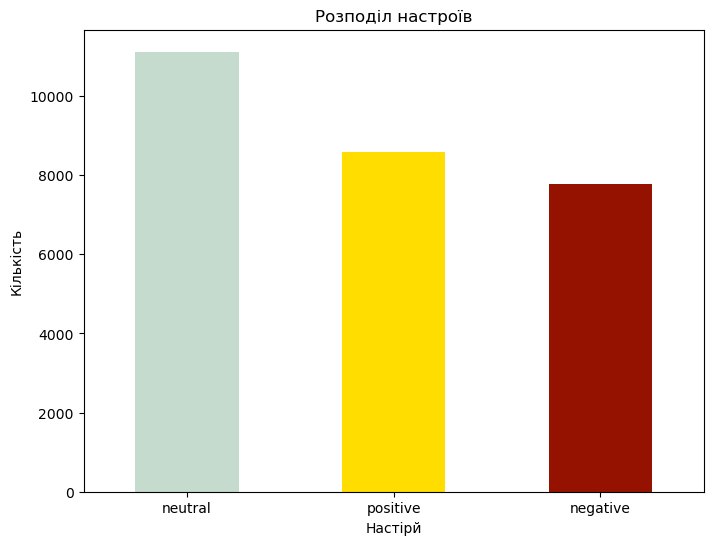

In [293]:
sentiment_counts = raw_df.sentiment.value_counts()

# Побудова гістограми
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['#c5dbce', '#ffdd00', '#961200'])
plt.title('Розподіл настроїв')
plt.xlabel('Настірй')
plt.ylabel('Кількість')
plt.xticks(rotation=0);

In [241]:
raw_df['text_len'] = [len(text) for text in raw_df['text']]

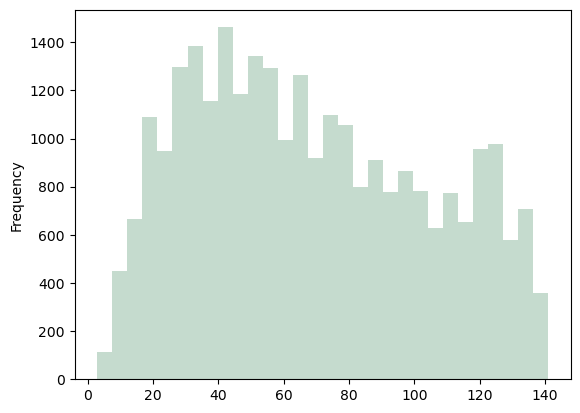

In [294]:
raw_df.text_len.plot.hist(bins=30, color='#c5dbce');

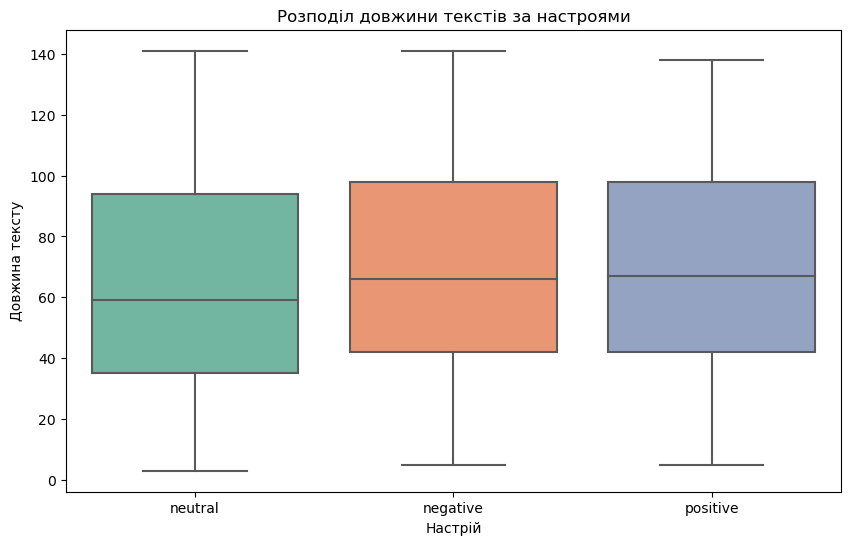

In [243]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_len', data=raw_df, palette="Set2")
plt.title('Розподіл довжини текстів за настроями')
plt.xlabel('Настрій')
plt.ylabel('Довжина тексту');

**Спостереження:** 
- `40%` текстів є нейтральними, `31%` позитивними та `28%` негативними. 
- Гістограма довжини текстів показує, що більшість текстів мають довжину в межах від 20 до 80 символів. 
- Boxplot розподілу довжини текстів за настроями вказує на те, що довжина текстів з нейтральним настроєм в середньому менша, ніж довжина позитивних чи негатиних текстів. З цього можна припустити, що для нейтральних текстів характерні коротші повідомлення, а для негативних та позитивних більш розгорнуті.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [244]:
nltk.download('punkt')

stemmer = SnowballStemmer("english")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Anastasiia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [245]:
def stemming_tokenizer(text):
    tokens = word_tokenize(text)
    return [stemmer.stem(token) for token in tokens]

In [246]:
vectorizer = CountVectorizer(tokenizer=stemming_tokenizer, stop_words='english', max_features=2000)

In [247]:
X = vectorizer.fit_transform(raw_df.text)

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 

In [248]:
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [249]:
bow_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Columns: 2000 entries, ! to ï¿½
dtypes: int64(2000)
memory usage: 419.3 MB


In [250]:
bow_df.head()

,!,#,$,%,&,',(,),*,+,...,yrs,yum,yummi,yup,zombi,{,|,},~,ï¿½
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [251]:
vectorizer.get_feature_names_out()

array(['!', '#', '$', ..., '}', '~', 'ï¿½'], dtype=object)

In [252]:
X.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [3, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [253]:
# Підрахунок частоти кожного слова
word_counts = np.asarray(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

# Створення DataFrame для частот
word_freq = pd.DataFrame({'word': words, 'count': word_counts})

# Сортування за частотою
word_freq_sorted = word_freq.sort_values(by='count', ascending=False)

In [254]:
print("Перші 10 слів за частотою:")
word_freq_sorted.head(10)

Перші 10 слів за частотою:


,word,count
0,!,15296
13,.,13773
85,`,11614
10,",",8454
8,*,4953
77,?,4266
15,...,3875
1496,s,3597
1713,t,3104
521,day,2417


In [255]:
print("\nОстанні 10 слів за частотою:")
word_freq_sorted.tail(10)


Останні 10 слів за частотою:


,word,count
58,4am,11
988,jb,11
510,dan,11
62,5th,11
66,7am,11
1451,repair,11
1458,resist,11
1459,respect,11
955,increas,11
638,entri,11


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



Спершу спробую натренувати Логістичну Регресію для цієї задачі.

In [256]:
X = bow_df
y = raw_df['sentiment']

In [257]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

In [258]:
log_reg = LogisticRegression(max_iter=1000, random_state=29)

In [259]:
log_reg.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000, random_state=29)

In [260]:
y_pred = log_reg.predict(X_test_bow)

In [261]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score (зважене середнє): {f1:.2f}")

F1-score (зважене середнє): 0.70


In [262]:
print("\nКласифікаційний звіт:")
print(classification_report(y_test, y_pred))


Класифікаційний звіт:
              precision    recall  f1-score   support

    negative       0.71      0.63      0.67      1545
     neutral       0.67      0.73      0.70      2241
    positive       0.76      0.74      0.75      1710

    accuracy                           0.70      5496
   macro avg       0.71      0.70      0.70      5496
weighted avg       0.71      0.70      0.70      5496



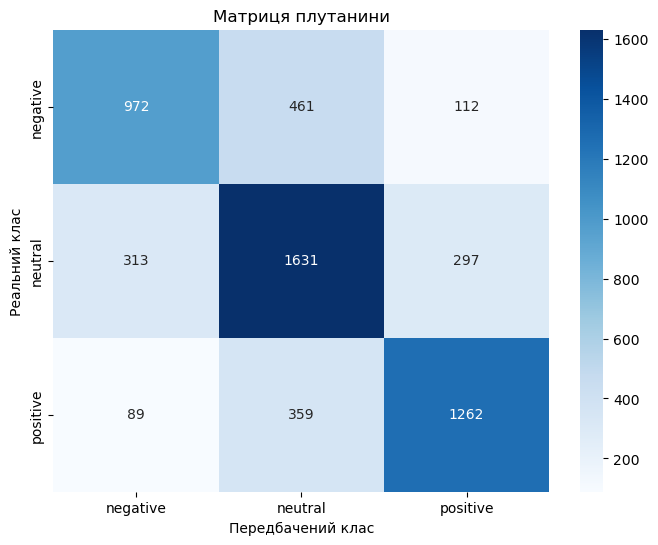

In [263]:
class_names = y_test.unique()

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_df, annot=True, cmap="Blues", fmt="d")
plt.title('Матриця плутанини')
plt.ylabel('Реальний клас')
plt.xlabel('Передбачений клас');

#### **Спостереження:** 

- **Precision**: Для класу `positive` модель показує найвищу точність `0.76`. Для класу `neutral` точність трохи нижча `0.67`, а для `negative` `0.71`.
- **Recall**: Найвищий Recall також спостерігається для класу `positive` `0.74`, тоді як для класу `negative` він найнижчий `0.63`. 
- **F1-score**: Найкраще значення F1-score знову ж таки для класу `positive` `0.75`, а найгірше для `negative` `0.67`.
 Це означає, що модель краще знаходить позитивні тексти, ніж негативні.

 
**Матриця плутанини** дозволяє побачити, як модель класифікує кожен клас:
- Модель правильно класифікувала `972` випадки як `negative`, але неправильно класифікувала `461` випадок як `neutral` і `112` як `positive`.
- Модель правильно класифікувала `1631` випадки як `neutral`, але неправильно класифікувала `313` як `negative` і `297` як `positive`.
- Модель правильно класифікувала `1262` випадки як `positive`, але неправильно класифікувала `359` як `neutral` і `89` як `negative`.

**Висновки:**
Модель добре працює з позитивними текстами (високі показники Precision, Recall та F1-score для класу "positive").
Нейтральні тексти також класифікуються непогано, хоча точність трохи нижча.
Негативні тексти найскладніші для класифікації, оскільки модель часто їх плутає з нейтральними.

**Наступні кроки:**
Спробую використати також дерева рішень для класифікації і порівняю результати моделй.

In [136]:
tree_clf = DecisionTreeClassifier(random_state=29)

In [137]:
tree_clf.fit(X_train_bow, y_train)

DecisionTreeClassifier(random_state=29)

In [138]:
y_pred_tree = tree_clf.predict(X_test_bow)

In [139]:
f1_tree = f1_score(y_test, y_pred_tree, average='weighted')
print(f"F1-score для дерева рішень (зважене середнє): {f1_tree:.2f}")

F1-score для дерева рішень (зважене середнє): 0.63


In [140]:
# Виведення класифікаційного звіту
print("\nКласифікаційний звіт для дерева рішень:")
print(classification_report(y_test, y_pred_tree))


Класифікаційний звіт для дерева рішень:
              precision    recall  f1-score   support

    negative       0.58      0.61      0.60      1545
     neutral       0.62      0.59      0.61      2241
    positive       0.68      0.70      0.69      1710

    accuracy                           0.63      5496
   macro avg       0.63      0.63      0.63      5496
weighted avg       0.63      0.63      0.63      5496



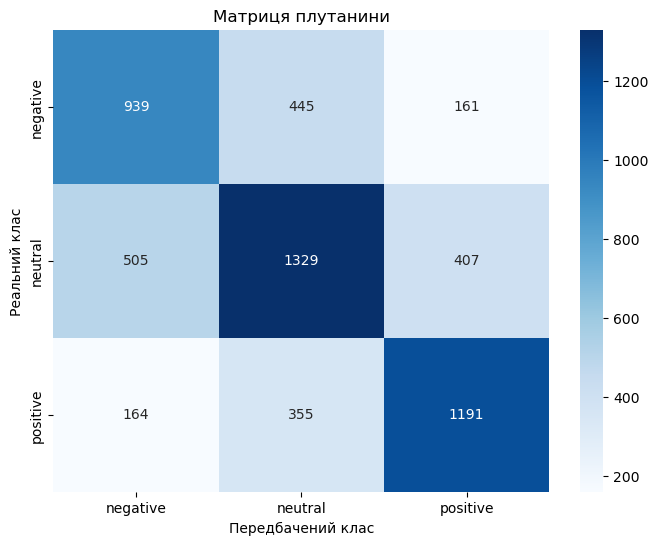

In [142]:
conf_matrix = confusion_matrix(y_test, y_pred_tree)
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_df, annot=True, cmap="Blues", fmt="d")
plt.title('Матриця плутанини')
plt.ylabel('Реальний клас')
plt.xlabel('Передбачений клас');

**Спостереження:** Базове дерево дало гірші показники `F1-score: 0.63`. Спробую пошукати кращі гіперпараметри за допомогою GridSearchCV.

In [145]:
param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [146]:
tree_clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(tree_clf, 
                           param_grid, 
                           cv=5, 
                           scoring='f1_weighted', 
                           verbose=1, 
                           n_jobs=-1)
grid_search.fit(X_train_bow, y_train)

print(f"Найкращі параметри: {grid_search.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Найкращі параметри: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}


In [147]:
best_tree_clf = grid_search.best_estimator_
y_pred_best_tree = best_tree_clf.predict(X_test_bow)

In [148]:
f1_best_tree = f1_score(y_test, y_pred_best_tree, average='weighted')
print(f"F1-score для дерева рішень (з оптимізованими параметрами): {f1_best_tree:.2f}")

F1-score для дерева рішень (з оптимізованими параметрами): 0.66


In [149]:
print("\nКласифікаційний звіт для оптимізованого дерева рішень:")
print(classification_report(y_test, y_pred_best_tree))


Класифікаційний звіт для оптимізованого дерева рішень:
              precision    recall  f1-score   support

    negative       0.63      0.59      0.61      1545
     neutral       0.63      0.67      0.65      2241
    positive       0.73      0.71      0.72      1710

    accuracy                           0.66      5496
   macro avg       0.66      0.66      0.66      5496
weighted avg       0.66      0.66      0.66      5496



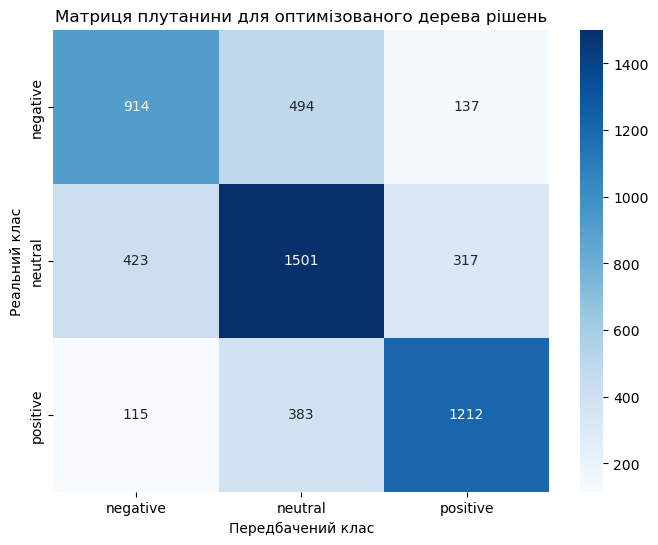

In [150]:
conf_matrix_best = confusion_matrix(y_test, y_pred_best_tree)
conf_matrix_df_best = pd.DataFrame(conf_matrix_best, index=class_names, columns=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df_best, annot=True, cmap="Blues", fmt="d")
plt.title('Матриця плутанини для оптимізованого дерева рішень')
plt.ylabel('Реальний клас')
plt.xlabel('Передбачений клас');

**Спостереження:** Вдалось підвищити показники `F1-score` до значення `0.66`, проте це всеодно гірший результат, ніж дала модель логістичної регресії. Спробую ще використати XGBoost.

In [200]:
X_xgb = raw_df['text']
y_xgb = raw_df['sentiment']

X_train_raw_xgb, X_test_raw_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=29)

vectorizer = CountVectorizer(token_pattern=r'\b\w+\b', max_features=2000, stop_words='english')

X_train_bow_xgb = vectorizer.fit_transform(X_train_raw_xgb)
X_test_bow_xgb = vectorizer.transform(X_test_raw_xgb)

label_encoder = LabelEncoder()
y_train_encoded_xgb = label_encoder.fit_transform(y_train_xgb)
y_test_encoded_xgb = label_encoder.transform(y_test_xgb)

In [201]:
# Перевіряємо форми даних
print(f"X_train_bow.shape: {X_train_bow_xgb.shape}")
print(f"y_train_encoded.shape: {y_train_encoded_xgb.shape}")

X_train_bow.shape: (21984, 2000)
y_train_encoded.shape: (21984,)


In [202]:
xgb_clf = XGBClassifier(random_state=29)
xgb_clf.fit(X_train_bow_xgb, y_train_encoded_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [203]:
y_pred_xgb = xgb_clf.predict(X_test_bow_xgb)

In [215]:
f1_xgb = f1_score(y_test_encoded_xgb, y_pred_xgb_xgb, average='weighted')
print(f"F1-score для XGBoost: {f1_xgb:.2f}")

F1-score для XGBoost: 0.69


In [214]:
print("\nКласифікаційний звіт для XGBoost:")
print(classification_report(y_test_encoded_xgb, y_pred_xgb))


Класифікаційний звіт для XGBoost:
              precision    recall  f1-score   support

           0       0.78      0.53      0.63      1545
           1       0.63      0.80      0.70      2241
           2       0.76      0.72      0.74      1710

    accuracy                           0.70      5496
   macro avg       0.72      0.68      0.69      5496
weighted avg       0.71      0.70      0.69      5496



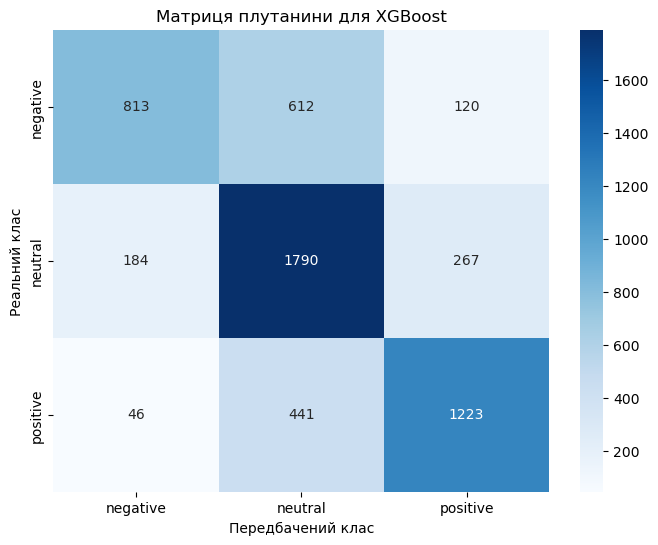

In [213]:
conf_matrix_xgb = confusion_matrix(y_test_encoded_xgb, y_pred_xgb)
conf_matrix_df_xgb = pd.DataFrame(conf_matrix_xgb, index=class_names, columns=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df_xgb, annot=True, cmap="Blues", fmt="d")
plt.title('Матриця плутанини для XGBoost')
plt.ylabel('Реальний клас')
plt.xlabel('Передбачений клас');

**Спостереження:** 
- Precision для класу **negative**: XGBoost показує вищу точність (`0.78` проти` 0.71`), але значно нижчий recall (`0.53` проти `0.63`), що знижує F1-score до `0.63` у порівнянні з `0.67` у логістичній регресії.
- Precision і recall для класу **neutral**: XGBoost краще визначає цей клас (recall `0.80` проти `0.73`), але precision трохи нижчий (`0.63` проти `0.67`), `F1-scor`e в обох моделях однаковий — `0.70`.
- Клас **positive**: Логістична регресія має трохи кращі показники (F1-score `0.75` проти `0.74`).

Логістична регресія має трохи вищий F1-score у порівнянні з XGBoost, але різниця невелика. А в порівнянні з деревами рішень вдалось підвищити показники `F1-score` до значення `0.69`. 

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [284]:
feature_importance_neg = pd.Series(log_reg.coef_[0],
                               index=vectorizer.get_feature_names_out(),
                               name='importance').sort_values(ascending=False)

In [285]:
pd.DataFrame(feature_importance_neg).round(2).head(10)

,importance
sad,2.71
suck,2.59
bore,2.24
fail,2.22
hate,2.20
sorri,2.18
worst,2.09
miss,2.09
disappoint,2.03
stupid,2.02


In [286]:
pd.DataFrame(feature_importance_neg).round(2).tail(10)

,importance
yum,-1.74
excit,-1.84
smile,-1.87
beauti,-1.87
cute,-2.06
amaz,-2.13
thank,-2.16
love,-2.24
awesom,-2.29
glad,-2.37


In [287]:
feature_importance_neutral = pd.Series(log_reg.coef_[1],
                                       index=vectorizer.get_feature_names_out(),
                                       name='importance').sort_values(ascending=False)

In [288]:
pd.DataFrame(feature_importance_neutral).round(2).head(10)

,importance
otherwis,1.30
lab,1.21
hide,1.16
ed,1.11
taco,1.07
instal,1.00
vancouv,0.98
couch,0.97
bio,0.93
resist,0.92


In [289]:
pd.DataFrame(feature_importance_neutral).round(2).tail(10)

,importance
hilari,-1.05
wors,-1.05
forum,-1.07
worst,-1.09
emot,-1.09
migrain,-1.11
nut,-1.17
congratul,-1.30
product,-1.31
bother,-1.56


In [290]:
feature_importance_positive = pd.Series(log_reg.coef_[2],
                                        index=vectorizer.get_feature_names_out(),
                                        name='importance').sort_values(ascending=False)

In [291]:
pd.DataFrame(feature_importance_positive).round(2).head(10)

,importance
awesom,2.64
thank,2.56
cute,2.44
love,2.40
excit,2.38
amaz,2.35
glad,2.21
happi,2.02
nice,2.01
great,2.00


In [292]:
pd.DataFrame(feature_importance_positive).round(2).tail(10)

,importance
tire,-1.92
bore,-1.97
hate,-1.99
unfortun,-2.00
exhaust,-2.00
shame,-2.32
jealous,-2.37
sorri,-2.38
suck,-2.60
sad,-2.82


**Спостереження**: 

`Негативний клас`:
- Найбільший вплив:
`sad, suck, bore, fail, hate` — це логічні слова для негативного сентименту.
- Найменший вплив:
`yum, excite, smile, "beautiful, cute` — це слова з позитивним сенсом, тому логічно, що їх вплив на негативний клас є від'ємним.

`Нейтральний клас`:
- Найбільший вплив:
`otherwise, lab, hide, ed, taco` — ці слова є відносно нейтральними, вони не мають чіткого емоційного забарвлення.
- Найменший вплив:
`worst, congratulation, bother, product` — `worst` та `bother` мають негативне забарвлення, тому їх вплив на нейтральний клас є логічно від'ємним.

`Позитивний клас`:
- Найбільший вплив:
`awesome, thank, cute, love, excite` — ці слова чітко асоціюються з позитивними емоціями.
- Найменший вплив:
`tire, bore, hate, unfortunate` — це негативні слова, тому їх вплив на позитивний клас є логічно від'ємним.

Загалом, результати виглядають логічно. Можна зробити висновок, що модель правильно вловлює семантику слів і їх вплив на визначення сентименту.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [298]:
# Створюємо об'єкт для обчислення TF-IDF
tfidf_vectorizer = TfidfVectorizer(tokenizer=stemming_tokenizer, stop_words='english', max_features=2000)

# Обчислюємо TF-IDF для наших документів
tfidf_matrix = tfidf_vectorizer.fit_transform(raw_df.text)

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 

In [299]:
# Виводимо результати у вигляді таблиці
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).round(2)
tfidf_df

,!,#,$,%,&,',(,),*,+,...,yrs,yum,yummi,yup,zombi,{,|,},~,ï¿½
0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.48,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.18,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.69,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27475,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27476,0.00,0.44,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27477,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27478,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.91,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [300]:
tfidf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Columns: 2000 entries, ! to ï¿½
dtypes: float64(2000)
memory usage: 419.3 MB


In [301]:
X = tfidf_df
y = raw_df['sentiment']

In [302]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

In [310]:
log_reg = LogisticRegression(max_iter=1000, random_state=29)

In [311]:
log_reg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=29)

In [312]:
y_pred = log_reg.predict(X_test_tfidf)

In [313]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score (зважене середнє): {f1:.2f}")

F1-score (зважене середнє): 0.70


In [314]:
print("\nКласифікаційний звіт:")
print(classification_report(y_test, y_pred))


Класифікаційний звіт:
              precision    recall  f1-score   support

    negative       0.71      0.61      0.66      1545
     neutral       0.65      0.74      0.69      2241
    positive       0.77      0.73      0.75      1710

    accuracy                           0.70      5496
   macro avg       0.71      0.69      0.70      5496
weighted avg       0.71      0.70      0.70      5496



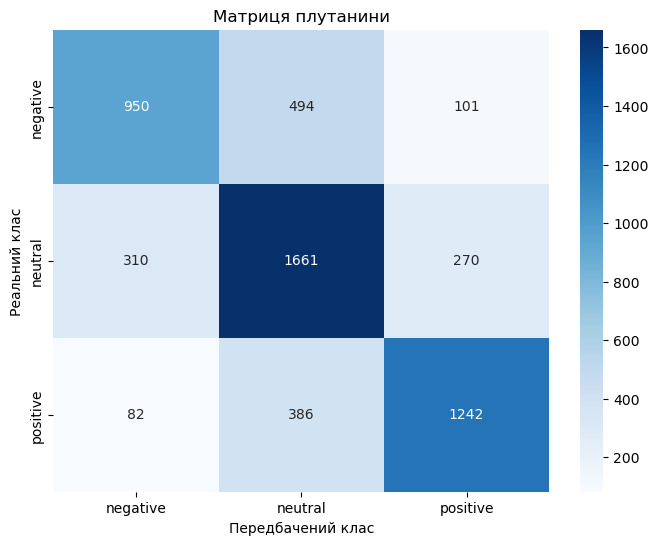

In [315]:
class_names = y_test.unique()

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_df, annot=True, cmap="Blues", fmt="d")
plt.title('Матриця плутанини')
plt.ylabel('Реальний клас')
plt.xlabel('Передбачений клас');

In [316]:
feature_importance_neg = pd.Series(log_reg.coef_[0],
                               index=tfidf_vectorizer.get_feature_names_out(),
                               name='importance').sort_values(ascending=False)

In [317]:
pd.DataFrame(feature_importance_neg).round(2).head(10)

,importance
sad,5.32
miss,5.19
suck,4.56
hate,4.46
sorri,4.24
bore,3.90
fail,3.62
stupid,3.39
tire,3.32
sick,3.27


In [318]:
pd.DataFrame(feature_importance_neg).round(2).tail(10)

,importance
cute,-2.41
better,-2.45
excit,-2.57
amaz,-2.72
great,-2.90
glad,-2.98
hope,-3.46
awesom,-3.54
thank,-4.14
love,-5.29


In [321]:
feature_importance_neutral = pd.Series(log_reg.coef_[1],
                                       index=tfidf_vectorizer.get_feature_names_out(),
                                       name='importance').sort_values(ascending=False)

In [322]:
pd.DataFrame(feature_importance_neutral).round(2).head(10)

,importance
aren,1.13
otherwis,1.00
hide,0.99
ed,0.94
couch,0.94
weren,0.93
goin,0.92
instal,0.92
?,0.89
],0.88


In [323]:
pd.DataFrame(feature_importance_neutral).round(2).tail(10)

,importance
worst,-1.71
fun,-1.76
thank,-1.76
bother,-1.77
fail,-1.82
nice,-1.98
stupid,-2.02
worri,-2.12
good,-2.28
happi,-2.67


In [324]:
feature_importance_positive = pd.Series(log_reg.coef_[2],
                                        index=tfidf_vectorizer.get_feature_names_out(),
                                        name='importance').sort_values(ascending=False)

In [325]:
pd.DataFrame(feature_importance_positive).round(2).head(10)

,importance
love,6.54
thank,5.90
awesom,5.07
happi,4.86
great,4.53
good,4.41
nice,4.37
excit,4.12
hope,4.11
amaz,3.95


In [326]:
pd.DataFrame(feature_importance_positive).round(2).tail(10)

,importance
jealous,-2.22
shame,-2.24
bad,-2.71
bore,-2.84
tire,-3.01
hate,-3.14
suck,-3.53
sorri,-3.74
miss,-4.19
sad,-4.32


#### **Спостереження:** 

- **Precision**: Для класу `positive` модель показує найвищу точність `0.77`. Для класу `neutral` точність трохи нижча `0.65`, а для `negative` `0.71`.
- **Recall**: Найвищий Recall також спостерігається для класу `positive` `0.73`, тоді як для класу `negative` він найнижчий `0.61`. 
- **F1-score**: Найкраще значення F1-score знову ж таки для класу `positive` `0.75`, а найгірше для `negative` `0.66`.
 Це означає, що модель краще знаходить позитивні тексти, ніж негативні.

 
**Матриця плутанини** дозволяє побачити, як модель класифікує кожен клас:
- Модель правильно класифікувала `950` випадки як `negative`, але неправильно класифікувала `494` випадок як `neutral` і `101` як `positive`.
- Модель правильно класифікувала `1661` випадки як `neutral`, але неправильно класифікувала `310` як `negative` і `270` як `positive`.
- Модель правильно класифікувала `1242` випадки як `positive`, але неправильно класифікувала `386` як `neutral` і `82` як `negative`.

**Висновки:**
Показники моделі натренованої на векторизованих текстах з векторизатором TfidfVectorizer майже такі ж самі як і з векторизацією bag of words. Метрики в деяких випадках відрізняють лише на `0.01-0.03` значення.

**Аналіз впливовості слів**: 

`Негативний клас`:
- Найбільший вплив:
`sad, miss, suck, hate, sorri` — окрім слова `sorri`, решта - це логічні слова для негативного сентименту.
- Найменший вплив:
`cute, better, excit, amaz, great` — це слова з позитивним сенсом, тому логічно, що їх вплив на негативний клас є від'ємним.

`Нейтральний клас`:
- Найбільший вплив:
`aren, otherwis, hide, ed, couch` — ці слова є відносно нейтральними, вони не мають чіткого емоційного забарвлення.
- Найменший вплив:
`happi, good, worri, stupid, nice` — мають чітке негативне або позитивне забарвлення, тому їх вплив на нейтральний клас є логічно від'ємним.

`Позитивний клас`:
- Найбільший вплив:
`love, thank, awesom, happy, great` — ці слова чітко асоціюються з позитивними емоціями.
- Найменший вплив:
`sad, miss, sorri, suck, hate` — це негативні слова, тому їх вплив на позитивний клас є логічно від'ємним.

Загалом, результати виглядають логічно і є подібними із результатами векторизатора bag of words. Можна також зробити висновок, що модель правильно вловлює семантику слів і їх вплив на визначення сентименту.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [329]:
errors_df = pd.DataFrame({
    'text': X_test_raw, 
    'true_sentiment': y_test,
    'predicted_sentiment': y_pred
})

errors_df = errors_df[errors_df['true_sentiment'] != errors_df['predicted_sentiment']]

In [330]:
len(errors_df)

1643

In [332]:
pd.set_option('display.max_colwidth', None)
errors_df.head(10)

,text,true_sentiment,predicted_sentiment
26458,I have a FACEBOOK but I use MYSPACE and TWITTER the most. I hardly check my Facebook..,negative,neutral
15229,It takes nearly 2 days to figure out what causes the mic problems at #euruko: Do not hold the mic at the bottom!,neutral,negative
15912,haha..i wont well il try not..lol... night chick..xxxxx,positive,neutral
26003,6 freakin days!! Just a thought...what would I have to look forward to after this?,negative,neutral
782,this day has beasted me.,negative,neutral
17434,"ready for a very busy, FUN day tomorrow! gotta keep myself busy when my lover is gone",positive,neutral
12865,I can`t help it if I`m a GRAMMAR NAZI!,neutral,negative
4585,heylo johnn (: im a huge fan. hope ur day is awesomee. cuzz im home sick and its kinda less than awesome.. anyways.. PEACE,neutral,positive
24933,The CD player in my car is broken. So much for listening to my Kidz Bop Happy Meal CD.,negative,positive
21262,Watching SNL gahhhhh Will Forte is soooooo funty!!!,positive,neutral


In [334]:
errors_df.predicted_sentiment.value_counts()

predicted_sentiment
neutral     880
negative    392
positive    371
Name: count, dtype: int64

Text(0.5, 1.0, 'Матриця плутанини для Logistic Regression')

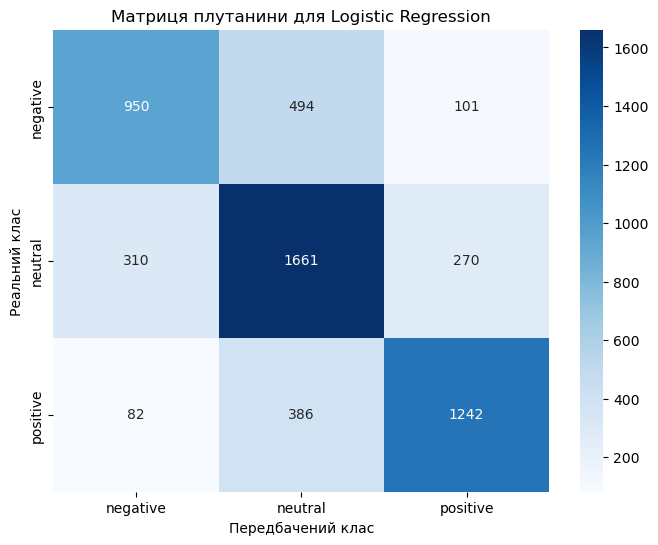

In [333]:
conf_matrix = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)

# Візуалізація матриці плутанини
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.xlabel('Передбачений клас')
plt.ylabel('Реальний клас')
plt.title('Матриця плутанини для Logistic Regression')

In [337]:
neutral_errors_df = errors_df[errors_df['predicted_sentiment'] == 'neutral']
neutral_errors_df.head(10)

,text,true_sentiment,predicted_sentiment
26458,I have a FACEBOOK but I use MYSPACE and TWITTER the most. I hardly check my Facebook..,negative,neutral
15912,haha..i wont well il try not..lol... night chick..xxxxx,positive,neutral
26003,6 freakin days!! Just a thought...what would I have to look forward to after this?,negative,neutral
782,this day has beasted me.,negative,neutral
17434,"ready for a very busy, FUN day tomorrow! gotta keep myself busy when my lover is gone",positive,neutral
21262,Watching SNL gahhhhh Will Forte is soooooo funty!!!,positive,neutral
7089,ughhh seriously hung over,negative,neutral
8007,"Yeah, but you`ve got admire someone who takes job satisfaction to the Nth degree",positive,neutral
8043,I envy everyone on AOTS...,positive,neutral
20703,Go Canada they made Nikkie Payne #1 comic well she is soo yeah but she is only funny to pervs or teens or people in my family,positive,neutral


**Спостереження:** 

1. Найбільше неправильно класифікованих текстів модель віднесла до класу `neutral`. Імовірно це через те, що в початковому наборі даних цей клаж переважав. Можна спробувати збалансувати класи за допомогою `Oversampling` або задати параметр `class_weight='balanced'` при ініціюванні моделі. 
2. Можливо, модель недооцінює важливі слова через те, що вони не потрапили в список. Можжна виключити занадто часті слова, а точніше символи, які не несуть інформації. 
3. Також можна спробувати додати до стоп-слів, ті слова які є впливовими для класів, але нелогічними. Тобто ті, які не несуть інформації ддля сентименту.
4. Також я би проаналізувала які слова найчастіше зустрічаються в помилково нейральних текстах. 

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model